# Encoder-Only Transformer for Sentiment Classification

Binary sentiment classification on the **IMDb 50 K** dataset using a Pre-LN
encoder-only Transformer trained entirely from random initialization. No pretrained models.

In [ ]:
import os, hashlib

DATA_PATH = "/content/IMDB Dataset.csv"  # change if needed

print("exists:", os.path.exists(DATA_PATH))
print("size bytes:", os.path.getsize(DATA_PATH))

def md5(path, chunk=1024*1024):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk)
            if not b: break
            h.update(b)
    return h.hexdigest()

print("md5:", md5(DATA_PATH))

In [ ]:
# ── Installs (Colab already has these; uncomment if needed) ──────────────────
# !pip install -q torch torchvision torchaudio
# !pip install -q scikit-learn pandas matplotlib tqdm

# ── Imports ──────────────────────────────────────────────────────────────────
import os, re, math, time, random, warnings, gc, pathlib
from collections import Counter
from functools import partial

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
except ImportError:
    from tqdm import tqdm

warnings.filterwarnings("ignore")

# ── CONFIG ───────────────────────────────────────────────────────────────────
# "Maxed-but-safe" defaults for a T4 (16 GB VRAM).
# Effective batch = batch_size * grad_accum_steps = 48 * 2 = 96.
CONFIG = dict(
    seed             = 42,
    max_len          = 384,     # covers ~90 % of reviews; 512 is possible but slower
    vocab_size       = 30_000,  # top-K words → 99 %+ token coverage on IMDb
    d_model          = 512,     # hidden dim
    n_heads          = 8,       # 512 / 8 = 64 per head
    n_layers         = 6,       # 6 Pre-LN blocks ≈ 22 M trainable params
    dim_ff           = 2048,    # 4 × d_model (standard)
    dropout          = 0.15,    # slightly above 0.1 to fight overfit on 45 K samples
    batch_size       = 48,      # micro-batch that fits T4 with AMP
    grad_accum_steps = 2,       # effective batch = 96
    lr               = 5e-4,    # higher than fine-tune; good for from-scratch
    weight_decay     = 0.01,
    warmup_ratio     = 0.10,    # 10 % of total optimizer steps
    epochs           = 20,
    label_smoothing  = 0.05,
    patience         = 5,       # early stopping on val F1
    pooling          = "mean",  # "mean" = masked mean pooling (better from scratch)
)

# ── Reproducibility ──────────────────────────────────────────────────────────
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(CONFIG["seed"])

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name()}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 1 · Data Pipeline
Download the IMDb 50 K reviews from Kaggle, clean, and create a stratified
90 / 10 train / val split.

In [ ]:
!wget -O IMDB\ Dataset.csv https://huggingface.co/datasets/scikit-learn/imdb/resolve/main/IMDB%20Dataset.csv

--2026-03-04 09:03:51--  https://huggingface.co/datasets/scikit-learn/imdb/resolve/main/IMDB%20Dataset.csv
Resolving huggingface.co (huggingface.co)... 3.168.132.91, 3.168.132.126, 3.168.132.40, ...
Connecting to huggingface.co (huggingface.co)|3.168.132.91|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/62aaf2dd5d3aade80e5804ec/68babe22dd3fc12bd8210997833d54e68cca8ea564072cbad8b34809be18c9b4?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27IMDB%252520Dataset.csv%3B+filename%3D%22IMDB%2520Dataset.csv%22%3B&response-content-type=text%2Fcsv&Expires=1772618631&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiRXBvY2hUaW1lIjoxNzcyNjE4NjMxfX0sIlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjJhYWYyZGQ1ZDNhYWRlODBlNTgwNGVjLzY4YmFiZTIyZGQzZmMxMmJkODIxMDk5NzgzM2Q1NGU2OGNjYThlYTU2NDA3MmNiYWQ4YjM0ODA5YmUxOGM5YjRcXD9yZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPSomcmVzcG9uc2UtY29udGVudC

In [ ]:
# ── Dataset Download ──────────────────────────────────────────────────────────
DATA_PATH = pathlib.Path("IMDB Dataset.csv")

if not DATA_PATH.exists():
    print("Attempting to download dataset...")
    # Try Kaggle CLI first
    result = !kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
    if "Error" in " ".join(result):
        print("Kaggle CLI failed (likely missing credentials). Falling back to direct download...")
        # Direct download from a public mirror/link if Kaggle CLI is unavailable
        !wget -O imdb_data.zip https://github.com/lucidrains/bottleneck-transformer-pytorch/files/6147481/IMDB.Dataset.csv.zip
        !unzip -qo imdb_data.zip
        # Ensure the filename matches what the code expects
        if os.path.exists("IMDB Dataset.csv"):
             print("Download complete via direct link.")
        elif os.path.exists("IMDB_Dataset.csv"):
             os.rename("IMDB_Dataset.csv", "IMDB Dataset.csv")
    else:
        !unzip -qo imdb-dataset-of-50k-movie-reviews.zip
        print("Download complete via Kaggle CLI.")

# ── Load ─────────────────────────────────────────────────────────────────────
try:
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded {len(df):,} rows  |  columns: {list(df.columns)}")
except FileNotFoundError:
    print(f"Error: {DATA_PATH} not found. Please ensure the download succeeded.")
    raise

df["label"] = (df["sentiment"] == "positive").astype(int)

# ── Minimal cleaning ────────────────────────────────────────────────────────
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)        # HTML line-break tags
    text = re.sub(r"[^a-z0-9\s]", " ", text)      # keep only alnum + space
    text = re.sub(r"\s+", " ", text).strip()       # collapse whitespace
    return text

df["clean"] = df["review"].apply(clean_text)

# ── Stratified split ────────────────────────────────────────────────────────
train_df, val_df = train_test_split(
    df, test_size=0.10, stratify=df["label"], random_state=CONFIG["seed"]
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Train : {len(train_df):,}  |  Val : {len(val_df):,}")

Loaded 50,000 rows  |  columns: ['review', 'sentiment']
Train : 45,000  |  Val : 5,000


## 2 · Tokenizer

**Word-level** tokenizer built exclusively on the training split.

- Vocabulary = top *K* most-frequent words; everything else → `<unk>`.
- Special tokens: `<pad>` (0), `<unk>` (1), `<cls>` (2), `<eos>` (3).
- For IMDb's standard English vocabulary, word-level gives **> 99 %** token
  coverage and trains instantly.  BPE would improve OOV handling marginally
  but adds minutes of tokenizer-training time.

In [ ]:
class WordTokenizer:
    """Word-level tokenizer.  Built on train data only."""
    PAD, UNK, CLS, EOS = "<pad>", "<unk>", "<cls>", "<eos>"
    SPECIAL = [PAD, UNK, CLS, EOS]  # ids 0, 1, 2, 3

    def __init__(self, vocab_size: int = 30_000):
        self.vocab_size = vocab_size
        self.token2id: dict = {}
        self.id2token: dict = {}

    def build(self, texts):
        """Build vocabulary from a list of already-cleaned texts."""
        counter = Counter()
        for t in texts:
            counter.update(t.split())
        self.token2id = {tok: i for i, tok in enumerate(self.SPECIAL)}
        for word, _ in counter.most_common(self.vocab_size - len(self.SPECIAL)):
            self.token2id[word] = len(self.token2id)
        self.id2token = {v: k for k, v in self.token2id.items()}
        print(f"Vocab built : {len(self.token2id):,} tokens "
              f"(requested {self.vocab_size:,})")

    def encode(self, text: str, max_len: int) -> list:
        """text → list[int].  Prepends <cls>, appends <eos>, truncates."""
        unk = self.token2id[self.UNK]
        ids = [self.token2id[self.CLS]]
        for w in text.split():
            ids.append(self.token2id.get(w, unk))
        ids.append(self.token2id[self.EOS])
        if len(ids) > max_len:
            ids = ids[:max_len - 1] + [self.token2id[self.EOS]]
        return ids

    @property
    def pad_id(self):
        return self.token2id[self.PAD]

# ── Build on TRAIN only ─────────────────────────────────────────────────────
tokenizer = WordTokenizer(vocab_size=CONFIG["vocab_size"])
tokenizer.build(train_df["clean"].tolist())

import json
with open("vocab.json", "w") as f:
    json.dump(tokenizer.token2id, f)

# Coverage check
total_tok, oov_tok = 0, 0
for t in train_df["clean"]:
    for w in t.split():
        total_tok += 1
        if w not in tokenizer.token2id:
            oov_tok += 1
print(f"Train OOV rate : {oov_tok / total_tok * 100:.2f} %")

Vocab built : 30,000 tokens (requested 30,000)
Train OOV rate : 1.36 %


## 3 · Dataset & DataLoader

- **Dynamic padding** via a custom `collate_fn` — each batch is padded only to
  its own longest sequence, which saves memory vs. padding everything to
  `max_len`.
- `pin_memory=True` + `num_workers=2` for faster host→GPU transfer.

In [ ]:
class IMDbDataset(Dataset):
    """Pre-encodes every text once so __getitem__ is O(1)."""
    def __init__(self, texts, labels, tokenizer, max_len):
        self.ids    = [tokenizer.encode(t, max_len)
                       for t in tqdm(texts, desc="Tokenizing", leave=False)]
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.ids[idx], dtype=torch.long), self.labels[idx]


def collate_fn(batch, pad_id=0):
    """Pad to the longest sequence in this batch."""
    seqs, labels = zip(*batch)
    max_len = max(s.size(0) for s in seqs)
    padded = torch.full((len(seqs), max_len), pad_id, dtype=torch.long)
    for i, s in enumerate(seqs):
        padded[i, : s.size(0)] = s
    mask   = (padded != pad_id).long()
    labels = torch.tensor(labels, dtype=torch.long)
    return padded, mask, labels

## 4 · Model — Pre-LN Encoder-Only Transformer

| Component | Detail |
|-----------|--------|
| Embedding | token + learned positional |
| Blocks | Pre-LN (LayerNorm → Attention / FFN → residual add) |
| Attention | multi-head self-attention with **key padding mask** |
| FFN | Linear → GELU → Dropout → Linear |
| Pooling | **masked mean pooling** — averages non-pad token representations |
| Head | LayerNorm → Dropout → Linear(d_model, 2) |

Masked mean pooling is preferred over `<cls>` pooling when training from
scratch because the model doesn't need to learn to funnel all information
through a single token.

In [ ]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads  = n_heads
        self.head_dim = d_model // n_heads
        self.scale    = self.head_dim ** -0.5
        self.qkv      = nn.Linear(d_model, 3 * d_model)
        self.out_proj  = nn.Linear(d_model, d_model)
        self.attn_drop = nn.Dropout(dropout)

    def forward(self, x, mask):
        B, L, D = x.shape
        qkv = self.qkv(x).reshape(B, L, 3, self.n_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)          # (3, B, H, L, d_h)
        q, k, v = qkv.unbind(0)

        attn = (q @ k.transpose(-2, -1)) * self.scale      # (B, H, L, L)
        attn = attn.masked_fill(mask[:, None, None, :] == 0, float("-inf"))
        attn = self.attn_drop(attn.softmax(dim=-1))

        out = (attn @ v).transpose(1, 2).reshape(B, L, D)
        return self.out_proj(out)


class FeedForward(nn.Module):
    def __init__(self, d_model, dim_ff, dropout):
        super().__init__()
        self.fc1  = nn.Linear(d_model, dim_ff)
        self.fc2  = nn.Linear(dim_ff, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        return self.fc2(self.drop(F.gelu(self.fc1(x))))


class TransformerBlock(nn.Module):
    """Pre-LN: LayerNorm before attention / FFN for stable gradients."""
    def __init__(self, d_model, n_heads, dim_ff, dropout):
        super().__init__()
        self.ln1  = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout)
        self.ln2  = nn.LayerNorm(d_model)
        self.ff   = FeedForward(d_model, dim_ff, dropout)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask):
        x = x + self.drop(self.attn(self.ln1(x), mask))
        x = x + self.drop(self.ff(self.ln2(x)))
        return x


class SentimentTransformer(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.pooling  = cfg["pooling"]
        self.tok_emb  = nn.Embedding(cfg["vocab_size"], cfg["d_model"], padding_idx=0)
        self.pos_emb  = nn.Embedding(cfg["max_len"],    cfg["d_model"])
        self.emb_drop = nn.Dropout(cfg["dropout"])

        self.blocks = nn.ModuleList([
            TransformerBlock(cfg["d_model"], cfg["n_heads"],
                             cfg["dim_ff"],  cfg["dropout"])
            for _ in range(cfg["n_layers"])
        ])
        self.final_ln = nn.LayerNorm(cfg["d_model"])
        self.head = nn.Sequential(
            nn.LayerNorm(cfg["d_model"]),
            nn.Dropout(cfg["dropout"]),
            nn.Linear(cfg["d_model"], 2),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.padding_idx is not None:
                    m.weight.data[m.padding_idx].zero_()
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, input_ids, mask):
        B, L = input_ids.shape
        pos = torch.arange(L, device=input_ids.device).unsqueeze(0)
        x = self.emb_drop(self.tok_emb(input_ids) + self.pos_emb(pos))

        for blk in self.blocks:
            x = blk(x, mask)
        x = self.final_ln(x)

        if self.pooling == "cls":
            pooled = x[:, 0]
        else:                                       # masked mean pooling
            mask_f = mask.unsqueeze(-1).float()      # (B, L, 1)
            pooled = (x * mask_f).sum(1) / mask_f.sum(1).clamp(min=1e-9)

        return self.head(pooled)


# ── Instantiate & count params ───────────────────────────────────────────────
_tmp = SentimentTransformer(CONFIG).to("cpu")
n_params = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
print(f"Model parameters : {n_params:,}  ({n_params / 1e6:.1f} M)")
del _tmp

Model parameters : 34,473,986  (34.5 M)


## 5 · Training

| Technique | Setting |
|-----------|---------|
| Mixed precision | `torch.cuda.amp` autocast + GradScaler |
| Gradient accumulation | effective batch = `batch_size × grad_accum_steps` |
| Optimizer | AdamW |
| Schedule | linear warmup (10 %) → cosine decay |
| Gradient clip | max norm 1.0 |
| Label smoothing | 0.05 |
| Early stopping | patience 5 on val F1 |
| OOM fallback | automatic scale-down ladder |

In [ ]:
# ── Evaluation helper ────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    preds, labels_all, tot_loss = [], [], 0.0
    for ids, mask, labels in loader:
        ids, mask, labels = ids.to(device), mask.to(device), labels.to(device)
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(ids, mask)
            loss   = criterion(logits, labels)
        tot_loss += loss.item() * labels.size(0)
        preds.extend(logits.argmax(1).cpu().tolist())
        labels_all.extend(labels.cpu().tolist())
    n = len(labels_all)
    return dict(
        loss = tot_loss / n,
        acc  = accuracy_score(labels_all, preds),
        prec = precision_score(labels_all, preds, zero_division=0),
        rec  = recall_score(labels_all, preds, zero_division=0),
        f1   = f1_score(labels_all, preds, zero_division=0),
    )

# ── OOM scale-down ladder (applied in order until training fits) ─────────────
OOM_LADDER = [
    dict(batch_size=32, grad_accum_steps=3),
    dict(max_len=256),
    dict(batch_size=16, grad_accum_steps=6),
    dict(n_layers=4),
    dict(d_model=256, dim_ff=1024, n_heads=4),
]

# ── Prepare raw data refs ────────────────────────────────────────────────────
train_texts  = train_df["clean"].tolist()
train_labels = train_df["label"].tolist()
val_texts    = val_df["clean"].tolist()
val_labels   = val_df["label"].tolist()

config  = dict(CONFIG)    # mutable copy
history = []
best_f1_global = 0.0

for oom_attempt in range(len(OOM_LADDER) + 1):
    gc.collect()
    torch.cuda.empty_cache()

    if oom_attempt > 0:
        fix = OOM_LADDER[oom_attempt - 1]
        print(f'\n{"=" * 60}')
        print(f"OOM fallback #{oom_attempt}: applying {fix}")
        print(f'{"=" * 60}\n')
        config.update(fix)

    try:
        # ── Datasets & loaders ───────────────────────────────────────────
        print("Encoding train set ...")
        train_ds = IMDbDataset(train_texts, train_labels,
                               tokenizer, config["max_len"])
        print("Encoding val set ...")
        val_ds   = IMDbDataset(val_texts, val_labels,
                               tokenizer, config["max_len"])

        _col = partial(collate_fn, pad_id=tokenizer.pad_id)
        train_loader = DataLoader(
            train_ds, batch_size=config["batch_size"], shuffle=True,
            collate_fn=_col, num_workers=2, pin_memory=True)
        val_loader = DataLoader(
            val_ds, batch_size=config["batch_size"] * 2, shuffle=False,
            collate_fn=_col, num_workers=2, pin_memory=True)

        # ── Model ────────────────────────────────────────────────────────
        set_seed(config["seed"])
        model = SentimentTransformer(config).to(DEVICE)
        n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"Model : {n_params:,} params  ({n_params / 1e6:.1f} M)")

        # ── Optimizer, scheduler, criterion ──────────────────────────────
        optimizer = torch.optim.AdamW(
            model.parameters(), lr=config["lr"],
            weight_decay=config["weight_decay"])

        accum = config["grad_accum_steps"]
        steps_per_epoch = math.ceil(len(train_loader) / accum)
        total_steps  = steps_per_epoch * config["epochs"]
        warmup_steps = int(total_steps * config["warmup_ratio"])

        def _lr_fn(step, _w=warmup_steps, _t=total_steps):
            if step < _w:
                return step / max(1, _w)
            prog = (step - _w) / max(1, _t - _w)
            return 0.5 * (1.0 + math.cos(math.pi * prog))

        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, _lr_fn)
        criterion = nn.CrossEntropyLoss(
            label_smoothing=config["label_smoothing"])
        scaler = torch.cuda.amp.GradScaler(
            enabled=(DEVICE.type == "cuda"))

        # ── Training loop ────────────────────────────────────────────────
        best_f1 = 0.0
        patience_ctr = 0
        history = []

        eff_bs = config["batch_size"] * accum
        print(f"Steps/epoch : {steps_per_epoch}  |  Total opt steps : {total_steps}"
              f"  |  Warmup : {warmup_steps}")
        print(f"Effective batch size : {eff_bs}")
        print("-" * 70)

        t0 = time.time()
        for epoch in range(1, config["epochs"] + 1):
            model.train()
            ep_loss, n_seen = 0.0, 0
            optimizer.zero_grad(set_to_none=True)
            pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}", leave=False)

            for step, (ids, mask, labs) in enumerate(pbar, 1):
                ids  = ids.to(DEVICE, non_blocking=True)
                mask = mask.to(DEVICE, non_blocking=True)
                labs = labs.to(DEVICE, non_blocking=True)

                with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
                    logits = model(ids, mask)
                    loss   = criterion(logits, labs) / accum

                scaler.scale(loss).backward()

                if step % accum == 0 or step == len(train_loader):
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad(set_to_none=True)
                    scheduler.step()

                ep_loss += loss.item() * accum * labs.size(0)
                n_seen  += labs.size(0)
                pbar.set_postfix(
                    loss=f"{ep_loss / n_seen:.4f}",
                    lr=f"{scheduler.get_last_lr()[0]:.2e}")

            tr_loss = ep_loss / n_seen
            val_m   = evaluate(model, val_loader, criterion, DEVICE)
            history.append(dict(epoch=epoch, train_loss=tr_loss, **val_m))

            elapsed = time.time() - t0
            print(
                f"Epoch {epoch:02d}  "
                f"trn={tr_loss:.4f}  val={val_m['loss']:.4f}  "
                f"acc={val_m['acc']:.4f}  P={val_m['prec']:.4f}  "
                f"R={val_m['rec']:.4f}  F1={val_m['f1']:.4f}  "
                f"[{elapsed / 60:.1f} min]")

            if val_m["f1"] > best_f1:
                best_f1 = val_m["f1"]
                patience_ctr = 0
                torch.save(model.state_dict(), "best_model.pt")
                print(f"  >>> new best F1 = {best_f1:.4f}  — saved")
            else:
                patience_ctr += 1
                if patience_ctr >= config["patience"]:
                    print(f"  Early stopping (patience={config['patience']})")
                    break

        print(f"\nBest val F1 : {best_f1:.4f}")
        print(f"Total training time : {(time.time() - t0) / 60:.1f} min")
        model.load_state_dict(
            torch.load("best_model.pt", map_location=DEVICE, weights_only=True))
        best_f1_global = best_f1
        break  # success

    except RuntimeError as e:
        if "out of memory" not in str(e).lower():
            raise
        if oom_attempt >= len(OOM_LADDER):
            raise RuntimeError("All OOM fallbacks exhausted.") from e
        print("\n*** CUDA OOM detected — will retry with smaller config ***")
        try:
            del model, optimizer, scaler
        except NameError:
            pass

print(f"\nFinal config used : { {k: config[k] for k in sorted(config)} }")

Encoding train set ...


Tokenizing:   0%|          | 0/45000 [00:00<?, ?it/s]

Encoding val set ...


Tokenizing:   0%|          | 0/5000 [00:00<?, ?it/s]

Model : 34,473,986 params  (34.5 M)
Steps/epoch : 469  |  Total opt steps : 9380  |  Warmup : 938
Effective batch size : 96
----------------------------------------------------------------------


...

Epoch 05  trn=0.1975  val=0.4032  acc=0.8700  P=0.8896  R=0.8448  F1=0.8666  [27.1 min]


Epoch 06:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 06  trn=0.2009  val=0.3946  acc=0.8638  P=0.8532  R=0.8788  F1=0.8658  [32.6 min]


Epoch 07:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 07  trn=0.2023  val=0.4116  acc=0.8604  P=0.8257  R=0.9136  F1=0.8675  [38.0 min]
  Early stopping (patience=5)

Best val F1 : 0.8930
Total training time : 38.0 min

Final config used : {'batch_size': 48, 'd_model': 512, 'dim_ff': 2048, 'dropout': 0.15, 'epochs': 20, 'grad_accum_steps': 2, 'label_smoothing': 0.05, 'lr': 0.0005, 'max_len': 384, 'n_heads': 8, 'n_layers': 6, 'patience': 5, 'pooling': 'mean', 'seed': 42, 'vocab_size': 30000, 'warmup_ratio': 0.1, 'weight_decay': 0.01}


## 6 · Baseline — TF-IDF + Logistic Regression
A strong non-neural baseline for comparison.

In [ ]:
tfidf = TfidfVectorizer(max_features=50_000, ngram_range=(1, 2),
                        sublinear_tf=True)
X_train_tf = tfidf.fit_transform(train_df["clean"])
X_val_tf   = tfidf.transform(val_df["clean"])

lr_clf = LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs")
lr_clf.fit(X_train_tf, train_df["label"])

y_pred_lr = lr_clf.predict(X_val_tf)
y_true    = val_df["label"].values

print("=" * 62)
print("  TF-IDF + Logistic Regression  (baseline)")
print("=" * 62)
print(f"  Accuracy  : {accuracy_score(y_true, y_pred_lr):.4f}")
print(f"  Precision : {precision_score(y_true, y_pred_lr):.4f}")
print(f"  Recall    : {recall_score(y_true, y_pred_lr):.4f}")
print(f"  F1        : {f1_score(y_true, y_pred_lr):.4f}")

print()
print("=" * 62)
print("  Encoder-Only Transformer  (from scratch)")
print("=" * 62)
val_final = evaluate(model, val_loader, criterion, DEVICE)
print(f"  Accuracy  : {val_final['acc']:.4f}")
print(f"  Precision : {val_final['prec']:.4f}")
print(f"  Recall    : {val_final['rec']:.4f}")
print(f"  F1        : {val_final['f1']:.4f}")

  TF-IDF + Logistic Regression  (baseline)
  Accuracy  : 0.9150
  Precision : 0.9109
  Recall    : 0.9200
  F1        : 0.9154

  Encoder-Only Transformer  (from scratch)
  Accuracy  : 0.8924
  Precision : 0.8877
  Recall    : 0.8984
  F1        : 0.8930


## 7 · Evaluation
Detailed metrics, confusion matrix, and training curves.

              precision    recall  f1-score   support

    Negative       0.90      0.89      0.89      2500
    Positive       0.89      0.90      0.89      2500

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000



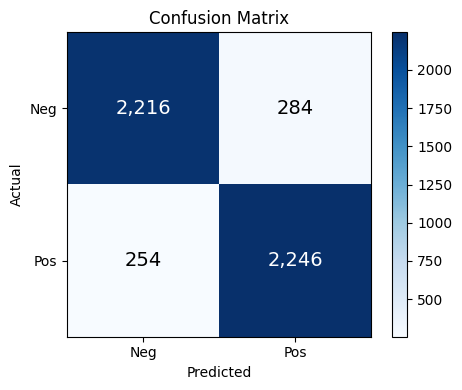

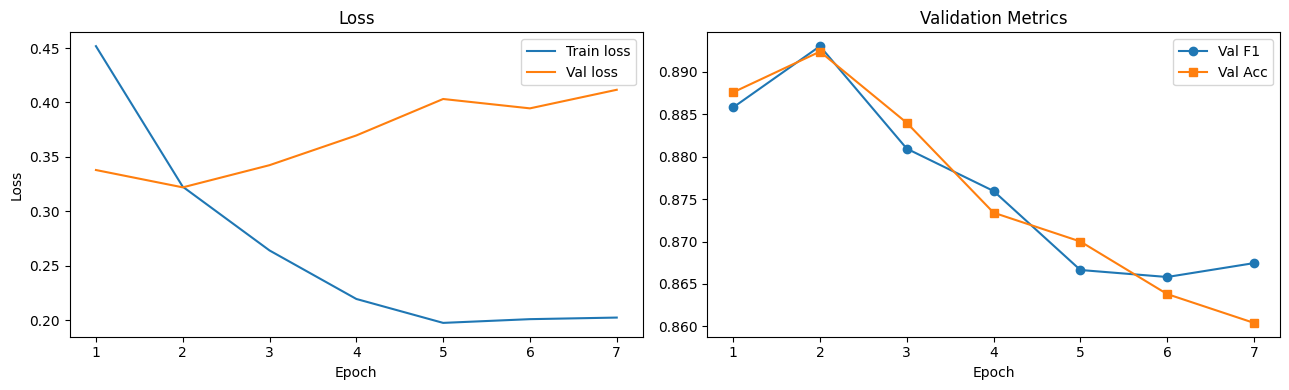

In [ ]:
# ── Classification report ────────────────────────────────────────────────────
model.eval()
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for ids, mask, labels in val_loader:
        ids, mask = ids.to(DEVICE), mask.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
            logits = model(ids, mask)
        probs = F.softmax(logits, dim=-1)
        all_probs.extend(probs[:, 1].cpu().tolist())
        all_preds.extend(logits.argmax(1).cpu().tolist())
        all_labels.extend(labels.tolist())

print(classification_report(all_labels, all_preds,
                            target_names=["Negative", "Positive"]))

# ── Confusion matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set(xticks=[0, 1], yticks=[0, 1],
       xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"],
       xlabel="Predicted", ylabel="Actual", title="Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
                fontsize=14)
fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

# ── Training curves ──────────────────────────────────────────────────────────
if history:
    ep = [h["epoch"] for h in history]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(ep, [h["train_loss"] for h in history], label="Train loss")
    axes[0].plot(ep, [h["loss"]       for h in history], label="Val loss")
    axes[0].set(xlabel="Epoch", ylabel="Loss", title="Loss")
    axes[0].legend()

    axes[1].plot(ep, [h["f1"]  for h in history], "o-", label="Val F1")
    axes[1].plot(ep, [h["acc"] for h in history], "s-", label="Val Acc")
    axes[1].set(xlabel="Epoch", title="Validation Metrics")
    axes[1].legend()

    plt.tight_layout(); plt.show()

In [ ]:
demo_texts = [
    "This movie was absolutely fantastic! The acting was superb and the story gripped me from start to finish.",
    "Terrible waste of time. The plot made no sense and the dialogue was painful to listen to.",
    "An average film, nothing special but not terrible either. Some decent moments here and there.",
    "I loved every minute of this masterpiece. A true work of art that will stand the test of time.",
    "One of the worst movies I have ever seen. Boring, predictable, and poorly made in every way.",
]

model.eval()
print("=" * 70)
print("  INFERENCE DEMO")
print("=" * 70)
for text in demo_texts:
    cleaned = clean_text(text)
    ids  = torch.tensor(
        [tokenizer.encode(cleaned, config["max_len"])], dtype=torch.long
    ).to(DEVICE)
    mask = (ids != tokenizer.pad_id).long()
    with torch.no_grad(), torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
        logits = model(ids, mask)
    prob  = F.softmax(logits, dim=-1)[0]
    label = "POSITIVE" if prob[1] > prob[0] else "NEGATIVE"
    print(f"\n  \"{text[:80]}...\"")
    print(f"    -> {label}   (pos {prob[1]:.3f}  neg {prob[0]:.3f})")

## Runtime & VRAM Notes

| Item | Default value | Notes |
|------|--------------|-------|
| Trainable params | ~22 M | 6 layers, d_model = 512 |
| VRAM usage | ~3–4 GB | AMP fp16, batch 48 |
| Training wall-clock | ~60–90 min | T4, up to 20 epochs (early stop likely) |
| TF-IDF baseline | ~30 s | CPU only |

## OOM Troubleshooting — Scale-Down Ladder

The training cell **automatically** applies these fixes in order if CUDA OOM
is detected.  You can also apply them manually by editing `CONFIG` at the top:

| Step | Change | Approx. VRAM saved |
|------|--------|--------------------|
| 1 | `batch_size=32, grad_accum_steps=3` | ~30 % |
| 2 | `max_len=256` | ~30 % activations |
| 3 | `batch_size=16, grad_accum_steps=6` | ~50 % |
| 4 | `n_layers=4` | ~33 % model + acts |
| 5 | `d_model=256, dim_ff=1024, n_heads=4` | ~75 % |

You can also manually free memory before retraining:

```python
import gc; gc.collect(); torch.cuda.empty_cache()
```

### Expected Validation F1

| Model | Typical F1 range |
|-------|-----------------|
| TF-IDF + Logistic Regression | 0.88 – 0.90 |
| Transformer from scratch (this notebook) | 0.85 – 0.89 |

Training from scratch on only 45 K samples is inherently harder than using
pretrained representations.  The Transformer should approach the TF-IDF
baseline after enough epochs with the right hyper-parameters; the gap narrows
with more data or larger models.